## 1. What this notebook computes

The field equations for $a_4(x_4)$ contain one equation with the second derivative
$a_4''$, the **evolution equation**

$$a_4''\,F(a_4') = \kappa\,(p_3 - p_t),$$

where $p_3 - p_t$ is the difference between the pressure along 3-space and the
pressure along the extra times (the **anisotropic stress**). If $p_3 - p_t$ is
given as a function of the time $x_4$, this is an ordinary differential equation
for $a_4$, and we can solve it step by step on the computer. This notebook

- takes $F$ and the other Lovelock components from the Revision record;
- writes a fourth-order Runge-Kutta solver (RK4) and tests it;
- integrates the equation for four **prescribed** stresses: zero (the linear
  member), a short pulse that raises the deflation rate of the extra times from
  $a_4' = H$ to $a_4' = 2H$, a stress that relaxes the rate from $2H$ back to $H$,
  and a constant stress in Einstein-Gauss-Bonnet gravity, where the equation
  breaks down at a finite time; along every one of these histories the extra
  times deflate exponentially at all times ($a_4' > 0$);
- compares each numerical history with its exact solution and measures the
  convergence order of RK4;
- computes the energy density and the pressures that each history requires, and
  checks that the constraint and the conservation law hold along the solution;
- draws six plots of $a_4$, its rate $a_4'$, and the scale factors $e^{a_4}$ of
  3-space and $e^{-a_4}$ of the deflating extra times.

## 2. How to run this notebook

**Step 1. What this notebook does and what it needs.**

Notebook 12c (Integrating the evolution equation of a4 for prescribed sources) is the
file `Revision/textbook/notebooks/12c_a4_evolution.ipynb` of the repository Dirac_claude.
It integrates the evolution equation of the author's metric, in which the second
derivative of a4 times the factor F equals kappa (p3 - p_t), with the fourth-order
Runge-Kutta method for prescribed anisotropic stresses p3 - p_t (zero, a pulse that
raises the deflation rate, a stress that relaxes it, a constant stress in
Einstein-Gauss-Bonnet gravity), with the extra times deflating along every history,
compares every history a4(x4) with its exact solution, measures the convergence order,
computes the energy density and the pressures that each history requires, checks
numerically that the constraint and the conservation law hold along the solutions, and
draws six teaching plots of a4, its rate and the scale factors of 3-space and of the
deflating extra times. At the end it reads the record on the Kohn-Sham states and
recomputes its numbers from the table of their integrated energy-momentum tensors. It
needs a computer with Windows 11, macOS or Linux, an internet connection for the
installation, the program Git, and Python 3.12 or newer (the notebooks were built with
Python 3.14.5) with these packages at exactly these versions: numpy 2.4.6, sympy 1.14.0,
mpmath 1.3.0, matplotlib 3.11.0, jupyterlab 4.4.10, nbformat 5.10.4, nbclient 0.10.2,
ipykernel 7.1.0 and nbconvert 7.16.6. The notebook itself imports numpy, sympy and
matplotlib; the other packages run Jupyter, the program that shows and runs notebooks. It
does not need Rust.

**Step 2. Install Git and Python (once per computer).**

A terminal is the window in which you type commands: on Windows the app Windows
PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux any
terminal (it runs the shell bash). Type every command of this section into a terminal
exactly as printed, one line at a time, and press Enter after each line.

Windows: download Git from https://git-scm.com/download/win and install it with the
default choices. Download Python from https://www.python.org/downloads/ and run the
installer; in its first window tick the box "Add python.exe to PATH" before you click
"Install Now".

macOS: download Python from https://www.python.org/downloads/ and run the installer. Then
open the app Terminal and run this command, which installs Git and the compiler tools:

macOS (zsh):

    xcode-select --install

Linux (Debian or Ubuntu; other distributions have packages of the same names): run these
two commands:

Linux (bash):

    sudo apt update
    sudo apt install git python3 python3-venv

Then close the terminal and open a NEW one (a terminal opened before the installation
does not know the new programs), and check the version of Python; it must print 3.12 or a
higher number:

Windows (PowerShell):

    py -3 --version

macOS (zsh) and Linux (bash):

    python3 --version

If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
3.12 with the following three commands, and in Step 3 type `python3.12` instead of
`python3` in the command that creates the environment:

Linux (bash), only when the version is too low:

    sudo add-apt-repository ppa:deadsnakes/ppa
    sudo apt update
    sudo apt install python3.12 python3.12-venv

**Step 3. Get the repository and install the packages (once per computer).**

The commands below download the repository (a few hundred megabytes; the folder then
needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
folder, create a private Python environment in the folder dirac-book-env inside your home
folder (a private environment is a folder with its own copy of Python and of the
packages, so that nothing else on your computer is changed), activate it (from then on
the commands `python` and `jupyter` typed in this terminal are those of the environment,
and the prompt starts with (dirac-book-env)), and install the packages at the pinned
versions (this downloads about 90 MB and takes a few minutes; the environment takes about
400 MB of disk space). If you have done this step before, for this or for another
notebook, skip it and go to Step 4; to get the newest version of the repository, run `git
pull` in the repository folder after Step 4.

Windows (PowerShell):

    cd $HOME
    git clone https://github.com/once-ere/Dirac_claude.git
    py -3 -m venv "$HOME\dirac-book-env"
    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

The line with `Set-ExecutionPolicy` allows PowerShell to run the activation script in
this one window only; it changes nothing permanently.

macOS (zsh):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

Linux (bash):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

**Step 4. In every new terminal: activate the environment and go into the repository
folder.**

Every later step starts in the repository folder with the environment active. Run these
lines whenever you open a new terminal (they do no harm if the environment is already
active):

Windows (PowerShell):

    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    cd "$HOME\Dirac_claude"

macOS (zsh) and Linux (bash):

    source ~/dirac-book-env/bin/activate
    cd ~/Dirac_claude

**Step 5. Run the notebook in JupyterLab.**

In the repository folder, with the environment active, run these two lines (the first one
goes into the folder of the notebooks):

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter lab 12c_a4_evolution.ipynb

JupyterLab opens in your web browser and shows the notebook (if no browser window opens,
copy the address that starts with `http://localhost:8888/lab` from the terminal into the
address bar of your browser). The name at the top right of the notebook must read Python
3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the label to its
left shows `[*]`; when it has finished, the label shows a number. The notebook has
finished when the last code cell shows a number; this takes about 15 seconds on a typical
laptop. Scroll to the end and compare the last printed lines with the lines in the step
"What the notebook writes and what you must see" below. To keep the results, save the
notebook (menu File > Save Notebook). To stop JupyterLab, choose the menu File > Shut
Down, or press Ctrl+C twice in the terminal.

**Step 6. Or run the notebook without a browser (headless).**

In the repository folder, with the environment active, run:

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter nbconvert --to notebook --execute --inplace 12c_a4_evolution.ipynb

This runs every cell from the top to the bottom and saves the results into the notebook
file. A failed check stops it with an error message that contains AssertionError and the
name of the check. If the command ends with a line that starts with `[NbConvertApp]
Writing` and shows no error, every check passed; open the notebook with `jupyter lab
12c_a4_evolution.ipynb` (in the same folder, without running the cells again) to read the
printed lines and see the figures.

**Step 7. What the notebook writes and what you must see.**

The notebook writes (or overwrites) these files:

- `Revision/textbook/figures/12c.captions.json`
- `Revision/textbook/figures/12c_1_linear_member.png`
- `Revision/textbook/figures/12c_2_stress_pulse.png`
- `Revision/textbook/figures/12c_3_required_source.png`
- `Revision/textbook/figures/12c_4_damped_deflation.png`
- `Revision/textbook/figures/12c_5_rk4_convergence.png`
- `Revision/textbook/figures/12c_6_gauss_bonnet_breakdown.png`

It changes no other file of the repository; running it headless or saving it in
JupyterLab also rewrites the notebook file itself. It does not use the internet while it
runs. The files it writes are the same files that are stored in the repository (on
another computer a figure may differ in a few bytes, which is harmless). To get the
stored versions back, run this command in the repository folder (it also undoes every
change you made yourself in the folder Revision/textbook):

Windows, macOS and Linux:

    git checkout -- Revision/textbook

Every check of the notebook prints a line that starts with PASS. At the end of the
notebook (the output of its last code cell) you must see exactly these lines:

    PASS all six figure files exist
    ALL 30 CHECKS PASSED (notebook 12c)

and the notebook must show 6 figures below the cells that draw them.

**Step 8. If something goes wrong.**

- "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
  without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
  again. If the error remains, another Python installation has registered its own kernel
  called python3; with the environment active, run the following command and start
  JupyterLab again:

      python -m ipykernel install --user --name python3

- "FileNotFoundError: The repository folder was not found": the notebook was opened from
  a copy outside the repository. Open the file
  `Revision/textbook/notebooks/12c_a4_evolution.ipynb` inside the folder Dirac_claude.
- "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
  downloaded before; skip the line with `git clone`.
- Windows: "running scripts is disabled on this system": run the line with
  `Set-ExecutionPolicy` and then the activation line again. "py is not recognized": use
  `python` instead of `py -3`; "python is not recognized": install Python again and tick
  "Add python.exe to PATH".
- Linux: "ensurepip is not available" when the environment is created: run `sudo apt
  install python3-venv` and repeat Step 3.
- "jupyter is not recognized" or "command not found: jupyter": the environment is not
  active; do Step 4. If the environment is active and the message stays, the programs
  jupyter-lab and jupyter-nbconvert are not in the folders where the terminal looks for
  programs (`python -m jupyter` does not help then: it has to find the same programs).
  Start them through Python itself, in the folder of the notebook: the first command
  below does what `jupyter lab` does, the second what the headless command does:

      python -m jupyterlab 12c_a4_evolution.ipynb
      python -m nbconvert --execute --inplace 12c_a4_evolution.ipynb

- Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
  loop" and zmq: this is a message of the package pyzmq, not an error; the run continues
  normally.
- A red box with "Matplotlib is building the font cache; this may take a moment." in the
  first run after the installation: this is a message, not an error; the run continues
  and the message does not come again.
- An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
  and Run All Cells; if it fails again, install the packages again with the pip commands
  of Step 3, because a different package version can change the last digits of a result.
- "FileNotFoundError" naming a4-equations.json: the notebook reads the Revision record of
  the repository. Run it inside the folder Revision/textbook/notebooks of a complete copy
  of the repository made with git clone, not on a copy of the notebook file alone.
- "RuntimeWarning: overflow" or "invalid value" below a cell after you changed a number:
  a changed coupling or stress drove a4' past the point where F vanishes; the notebook as
  distributed stops every integration before that point. Undo the change or lower the
  stress.

The first code cell below (the set-up cell) repeats these instructions as comments; then
it imports the packages, finds the repository folder and defines the helpers
`save_figure` (saves a figure and shows it), `check` (stops with an AssertionError when a
check fails, prints a PASS line when it passes), `report` (prints a key number as a
RESULT line) and `all_checks_passed` (prints the last line).

In [1]:
# HOW TO RUN NOTEBOOK 12c (the complete instructions)
#
# STEP 1. WHAT THIS NOTEBOOK DOES AND WHAT IT NEEDS.
#
# Notebook 12c (Integrating the evolution equation of a4 for prescribed sources) is the
# file Revision/textbook/notebooks/12c_a4_evolution.ipynb of the repository Dirac_claude.
# It integrates the evolution equation of the author's metric, in which the second
# derivative of a4 times the factor F equals kappa (p3 - p_t), with the fourth-order
# Runge-Kutta method for prescribed anisotropic stresses p3 - p_t (zero, a pulse that
# raises the deflation rate, a stress that relaxes it, a constant stress in
# Einstein-Gauss-Bonnet gravity), with the extra times deflating along every history,
# compares every history a4(x4) with its exact solution, measures the convergence order,
# computes the energy density and the pressures that each history requires, checks
# numerically that the constraint and the conservation law hold along the solutions, and
# draws six teaching plots of a4, its rate and the scale factors of 3-space and of the
# deflating extra times. At the end it reads the record on the Kohn-Sham states and
# recomputes its numbers from the table of their integrated energy-momentum tensors. It
# needs a computer with Windows 11, macOS or Linux, an internet connection for the
# installation, the program Git, and Python 3.12 or newer (the notebooks were built with
# Python 3.14.5) with these packages at exactly these versions: numpy 2.4.6, sympy
# 1.14.0, mpmath 1.3.0, matplotlib 3.11.0, jupyterlab 4.4.10, nbformat 5.10.4, nbclient
# 0.10.2, ipykernel 7.1.0 and nbconvert 7.16.6. The notebook itself imports numpy, sympy
# and matplotlib; the other packages run Jupyter, the program that shows and runs
# notebooks. It does not need Rust.
#
# STEP 2. INSTALL GIT AND PYTHON (ONCE PER COMPUTER).
#
# A terminal is the window in which you type commands: on Windows the app Windows
# PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux
# any terminal (it runs the shell bash). Type every command of this section into a
# terminal exactly as printed, one line at a time, and press Enter after each line.
#
# Windows: download Git from https://git-scm.com/download/win and install it with the
# default choices. Download Python from https://www.python.org/downloads/ and run the
# installer; in its first window tick the box "Add python.exe to PATH" before you click
# "Install Now".
#
# macOS: download Python from https://www.python.org/downloads/ and run the installer.
# Then open the app Terminal and run this command, which installs Git and the compiler
# tools:
#
# macOS (zsh):
#     xcode-select --install
#
# Linux (Debian or Ubuntu; other distributions have packages of the same names): run
# these two commands:
#
# Linux (bash):
#     sudo apt update
#     sudo apt install git python3 python3-venv
#
# Then close the terminal and open a NEW one (a terminal opened before the installation
# does not know the new programs), and check the version of Python; it must print 3.12 or
# a higher number:
#
# Windows (PowerShell):
#     py -3 --version
#
# macOS (zsh) and Linux (bash):
#     python3 --version
#
# If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
# 3.12 with the following three commands, and in Step 3 type python3.12 instead of
# python3 in the command that creates the environment:
#
# Linux (bash), only when the version is too low:
#     sudo add-apt-repository ppa:deadsnakes/ppa
#     sudo apt update
#     sudo apt install python3.12 python3.12-venv
#
# STEP 3. GET THE REPOSITORY AND INSTALL THE PACKAGES (ONCE PER COMPUTER).
#
# The commands below download the repository (a few hundred megabytes; the folder then
# needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
# folder, create a private Python environment in the folder dirac-book-env inside your
# home folder (a private environment is a folder with its own copy of Python and of the
# packages, so that nothing else on your computer is changed), activate it (from then on
# the commands python and jupyter typed in this terminal are those of the environment,
# and the prompt starts with (dirac-book-env)), and install the packages at the pinned
# versions (this downloads about 90 MB and takes a few minutes; the environment takes
# about 400 MB of disk space). If you have done this step before, for this or for another
# notebook, skip it and go to Step 4; to get the newest version of the repository, run
# git pull in the repository folder after Step 4.
#
# Windows (PowerShell):
#     cd $HOME
#     git clone https://github.com/once-ere/Dirac_claude.git
#     py -3 -m venv "$HOME\dirac-book-env"
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# The line with Set-ExecutionPolicy allows PowerShell to run the activation script in
# this one window only; it changes nothing permanently.
#
# macOS (zsh):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# Linux (bash):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# STEP 4. IN EVERY NEW TERMINAL: ACTIVATE THE ENVIRONMENT AND GO INTO THE REPOSITORY
# FOLDER.
#
# Every later step starts in the repository folder with the environment active. Run these
# lines whenever you open a new terminal (they do no harm if the environment is already
# active):
#
# Windows (PowerShell):
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     cd "$HOME\Dirac_claude"
#
# macOS (zsh) and Linux (bash):
#     source ~/dirac-book-env/bin/activate
#     cd ~/Dirac_claude
#
# STEP 5. RUN THE NOTEBOOK IN JUPYTERLAB.
#
# In the repository folder, with the environment active, run these two lines (the first
# one goes into the folder of the notebooks):
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter lab 12c_a4_evolution.ipynb
#
# JupyterLab opens in your web browser and shows the notebook (if no browser window
# opens, copy the address that starts with http://localhost:8888/lab from the terminal
# into the address bar of your browser). The name at the top right of the notebook must
# read Python 3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the
# label to its left shows [*]; when it has finished, the label shows a number. The
# notebook has finished when the last code cell shows a number; this takes about 15
# seconds on a typical laptop. Scroll to the end and compare the last printed lines with
# the lines in the step "What the notebook writes and what you must see" below. To keep
# the results, save the notebook (menu File > Save Notebook). To stop JupyterLab, choose
# the menu File > Shut Down, or press Ctrl+C twice in the terminal.
#
# STEP 6. OR RUN THE NOTEBOOK WITHOUT A BROWSER (HEADLESS).
#
# In the repository folder, with the environment active, run:
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter nbconvert --to notebook --execute --inplace 12c_a4_evolution.ipynb
#
# This runs every cell from the top to the bottom and saves the results into the notebook
# file. A failed check stops it with an error message that contains AssertionError and
# the name of the check. If the command ends with a line that starts with [NbConvertApp]
# Writing and shows no error, every check passed; open the notebook with jupyter lab
# 12c_a4_evolution.ipynb (in the same folder, without running the cells again) to read
# the printed lines and see the figures.
#
# STEP 7. WHAT THE NOTEBOOK WRITES AND WHAT YOU MUST SEE.
#
# The notebook writes (or overwrites) these files:
#
# - Revision/textbook/figures/12c.captions.json
# - Revision/textbook/figures/12c_1_linear_member.png
# - Revision/textbook/figures/12c_2_stress_pulse.png
# - Revision/textbook/figures/12c_3_required_source.png
# - Revision/textbook/figures/12c_4_damped_deflation.png
# - Revision/textbook/figures/12c_5_rk4_convergence.png
# - Revision/textbook/figures/12c_6_gauss_bonnet_breakdown.png
#
# It changes no other file of the repository; running it headless or saving it in
# JupyterLab also rewrites the notebook file itself. It does not use the internet while
# it runs. The files it writes are the same files that are stored in the repository (on
# another computer a figure may differ in a few bytes, which is harmless). To get the
# stored versions back, run this command in the repository folder (it also undoes every
# change you made yourself in the folder Revision/textbook):
#
# Windows, macOS and Linux:
#     git checkout -- Revision/textbook
#
# Every check of the notebook prints a line that starts with PASS. At the end of the
# notebook (the output of its last code cell) you must see exactly these lines:
#
#     PASS all six figure files exist
#     ALL 30 CHECKS PASSED (notebook 12c)
#
# and the notebook must show 6 figures below the cells that draw them.
#
# STEP 8. IF SOMETHING GOES WRONG.
#
# - "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
#   without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
#   again. If the error remains, another Python installation has registered its own
#   kernel called python3; with the environment active, run the following command and
#   start JupyterLab again:
#     python -m ipykernel install --user --name python3
# - "FileNotFoundError: The repository folder was not found": the notebook was opened
#   from a copy outside the repository. Open the file
#   Revision/textbook/notebooks/12c_a4_evolution.ipynb inside the folder Dirac_claude.
# - "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
#   downloaded before; skip the line with git clone.
# - Windows: "running scripts is disabled on this system": run the line with
#   Set-ExecutionPolicy and then the activation line again. "py is not recognized": use
#   python instead of py -3; "python is not recognized": install Python again and tick
#   "Add python.exe to PATH".
# - Linux: "ensurepip is not available" when the environment is created: run sudo apt
#   install python3-venv and repeat Step 3.
# - "jupyter is not recognized" or "command not found: jupyter": the environment is not
#   active; do Step 4. If the environment is active and the message stays, the programs
#   jupyter-lab and jupyter-nbconvert are not in the folders where the terminal looks for
#   programs (python -m jupyter does not help then: it has to find the same programs).
#   Start them through Python itself, in the folder of the notebook: the first command
#   below does what jupyter lab does, the second what the headless command does:
#     python -m jupyterlab 12c_a4_evolution.ipynb
#     python -m nbconvert --execute --inplace 12c_a4_evolution.ipynb
# - Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
#   loop" and zmq: this is a message of the package pyzmq, not an error; the run
#   continues normally.
# - A red box with "Matplotlib is building the font cache; this may take a moment." in
#   the first run after the installation: this is a message, not an error; the run
#   continues and the message does not come again.
# - An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
#   and Run All Cells; if it fails again, install the packages again with the pip
#   commands of Step 3, because a different package version can change the last digits of
#   a result.
# - "FileNotFoundError" naming a4-equations.json: the notebook reads the Revision record
#   of the repository. Run it inside the folder Revision/textbook/notebooks of a complete
#   copy of the repository made with git clone, not on a copy of the notebook file alone.
# - "RuntimeWarning: overflow" or "invalid value" below a cell after you changed a
#   number: a changed coupling or stress drove a4' past the point where F vanishes; the
#   notebook as distributed stops every integration before that point. Undo the change or
#   lower the stress.
#
# ---------------------------------------------------------------------------------------
# =======================================================================================
# THE SET-UP (the same in every notebook of this book; it computes no physics)
# =======================================================================================
import json  # reads and writes JSON files (text files that hold names and numbers)
import os  # reads the environment variable TEXTBOOK_OUTPUT_ROOT (explained below)
import textwrap  # breaks long printed text into lines of at most 89 characters
from pathlib import Path  # file and folder paths that work on Windows, macOS and Linux

import matplotlib  # the plotting package
import matplotlib.pyplot as plt  # its drawing functions, called plt by convention
from IPython.display import Image, display  # shows a saved picture below a cell

NOTEBOOK_ID = "12c"  # this notebook: chapter 12, example c


def find_repository_root():
    """Return the repository folder (Dirac_claude).

    Jupyter runs a notebook in the folder that holds it.  Starting there, go up one
    folder at a time until a folder contains Revision/textbook/requirements.txt (the
    list of the book's packages); that folder is the repository."""
    here = Path.cwd().resolve()  # the folder in which this notebook runs
    for folder in [here, *here.parents]:  # this folder, its parent, its grandparent ...
        if (folder / "Revision" / "textbook" / "requirements.txt").is_file():
            return folder
    raise FileNotFoundError(
        "The repository folder was not found: open this notebook inside the folder "
        "Revision/textbook/notebooks of the repository Dirac_claude")


# The repository folder.  It is never printed: it differs from computer to computer,
# and the printed output of a notebook must not.
REPO = find_repository_root()
# Every file is WRITTEN below OUTPUT_ROOT.  OUTPUT_ROOT is the repository folder unless
# the environment variable TEXTBOOK_OUTPUT_ROOT names another folder; the book's
# checking tool sets it, so that a check run writes into a scratch folder instead.
OUTPUT_ROOT = Path(os.environ.get("TEXTBOOK_OUTPUT_ROOT", str(REPO)))


def repository_file(relative):
    """The path of the repository file relative, for READING (a Revision record)."""
    return REPO / relative


def output_file(relative):
    """The path at which to WRITE the repository file relative (its folder is made)."""
    path = OUTPUT_ROOT / relative
    path.parent.mkdir(parents=True, exist_ok=True)
    return path


def say(text):
    """Print text in lines of at most 89 characters (the width of a page of the book)."""
    print(textwrap.fill(str(text), width=89, subsequent_indent="    "))


matplotlib.rcdefaults()  # ignore personal matplotlib settings: same figures everywhere
plt.rcParams.update({"figure.figsize": (7.0, 4.2), "font.size": 10.0,
                     "axes.grid": True, "grid.alpha": 0.3})

FIGURE_FOLDER = "Revision/textbook/figures"  # where the figures are saved
CAPTION_FILE = f"{FIGURE_FOLDER}/{NOTEBOOK_ID}.captions.json"  # their captions
FIGURE_NUMBERS = {}  # figure name -> its number k (file name <id>_<k>_<name>.png)
CAPTIONS = {}  # figure file name -> caption, written to CAPTION_FILE after every figure
# Start with an empty captions file ({} is an empty JSON dictionary); save_figure fills
# it.  newline="\n" writes the same line ends on Windows, macOS and Linux.
output_file(CAPTION_FILE).write_text("{}\n", encoding="utf-8", newline="\n")


def save_figure(fig, name, caption):
    """Save the figure fig as Revision/textbook/figures/<id>_<k>_<name>.png, record its
    caption in CAPTION_FILE, show the saved picture below the cell and close the figure.
    k counts the figures of the notebook 1, 2, 3, ...; a cell run again keeps its k."""
    number = FIGURE_NUMBERS.setdefault(name, len(FIGURE_NUMBERS) + 1)
    file_name = f"{NOTEBOOK_ID}_{number}_{name}.png"
    relative = f"{FIGURE_FOLDER}/{file_name}"
    # dpi=150: 150 dots per inch.  bbox_inches="tight": cut away the empty margin.
    # metadata={"Software": None}: no program name is stored in the PNG file, so that
    # every run writes exactly the same bytes.
    fig.savefig(output_file(relative), dpi=150, bbox_inches="tight",
                metadata={"Software": None})
    plt.close(fig)  # forget the figure, so that Jupyter does not draw it a second time
    CAPTIONS[file_name] = caption
    output_file(CAPTION_FILE).write_text(
        json.dumps(CAPTIONS, indent=1, sort_keys=True) + "\n", encoding="utf-8",
        newline="\n")
    display(Image(filename=str(output_file(relative))),
            metadata={"textbook_figure": file_name})  # the saved picture itself
    say(f"Figure {NOTEBOOK_ID}.{number} saved as {relative}")


PASSED = []  # the names of the checks that passed, in order


def check(condition, name, record=None):
    """A check.  If condition is False, stop with an AssertionError that names the
    check (an if statement is used instead of assert, because python -O would skip an
    assert).  Otherwise print "PASS <name>" and, when the check reproduces a Revision
    record, a second line naming the record file and its check."""
    if not condition:
        raise AssertionError(f"check failed: {name}")
    PASSED.append(name)
    say(f"PASS {name}")
    if record is not None:
        say(f"     reproduces {record}")


def report(label, value, unit=""):
    """Print a key number as a line "RESULT <label> = <value> <unit>"."""
    say(f"RESULT {label} = {value}" + (f" {unit}" if unit else ""))


def all_checks_passed():
    """Print the last line of the notebook: how many checks passed."""
    print(f"ALL {len(PASSED)} CHECKS PASSED (notebook {NOTEBOOK_ID})")


say(f"Set-up of notebook {NOTEBOOK_ID} complete: repository folder found, helpers "
    "defined.")

Set-up of notebook 12c complete: repository folder found, helpers defined.


## 3. The words used in this notebook

- **Ordinary differential equation (ODE)**: an equation for an unknown function of
  one variable (here $a_4(x_4)$) that contains its derivatives.
- **Initial value problem**: an ODE together with the starting values, here
  $a_4(0) = 0$ and the starting rate $a_4'(0)$.
- **First-order system**: the second-order equation written as two first-order
  ones, $\frac{d}{dx_4}a_4 = v$ and $\frac{d}{dx_4}v = \kappa(p_3 - p_t)/F(v)$,
  with $v = a_4'$.
- **RK4** (Runge-Kutta of fourth order): a rule that advances the solution by one
  step $h$ using four evaluations of the right-hand side; its error shrinks like
  $h^4$.
- **Convergence order**: the power $q$ in "error $\approx$ constant $\times h^q$";
  halving $h$ divides the error by $2^q$.
- **Anisotropic stress** $\Delta = p_3 - p_t$: the difference of the pressures along
  3-space and along the extra times.
- **Prescribed source**: a source that we choose by hand to see what the equations
  do (status ASSUMED); it is not derived from any field of the theory.
- **Scale factor**: the factor by which lengths along a direction grow:
  $e^{a_4}$ for 3-space and $e^{-a_4}$ for the extra times $x_5, x_6, x_7$ (times
  the common factor $\sin^{1/6} z$, which does not change with $x_4$).
- **Constraint**: the time component of the field equations, which fixes the
  energy density $\rho$ from $a_4'$; **conservation**: $\rho' = -3a_4'(p_3 - p_t)$.
- **Deflation rate**: the rate $a_4'$. While $a_4' > 0$ the scale factor
  $e^{-a_4}$ of the extra times shrinks exponentially, at the momentary rate $a_4'$.
- **Canonical history**: the author's metric leaves the function $a_4(x_4)$ free;
  the author requires only that the extra times deflate ($a_4' > 0$). The linear
  member with the constant rate $a_4' = AH$ and $A = 1$ is the canonical history
  of the Revision record (ASSUMED, a prescribed choice); this notebook also uses
  the faster member $A = 2$.
- **Breakdown**: a point where $F(a_4') = 0$, so that the evolution equation can no
  longer be solved for $a_4''$.
- **Units**: $H = 1$ and $\kappa = 1$: the time $x_4$ is measured in units of
  $1/H$, $a_4'$ in units of $H$, $\kappa\rho$ and the pressures in units of $H^2$.

## 4. The physical and mathematical situation

For a source that does not depend on $x_8$ and has no mixed components, the
field equations of the author's metric are (Revision record `a4-equations.json`)

$$\kappa\rho = -\Big(\sum_k\alpha_k E_{(k)}{}^{x_4}{}_{x_4}(a_4') + \Lambda\Big),
\qquad \kappa p_8 = \sum_k\alpha_k E_{(k)}{}^{x_8}{}_{x_8}(a_4') + \Lambda,$$
$$a_4''\,F(a_4') = \kappa(p_3 - p_t),\qquad p_3 + p_t = 2p_8.$$

We choose (prescribe) the anisotropic stress $\Delta(x_4) = p_3 - p_t$ and the
starting values $a_4(0)$, $a_4'(0)$. The evolution equation then determines
$a_4(x_4)$; the first equation gives the energy density, the second the hidden
pressure, and $p_3 = p_8 + \Delta/2$, $p_t = p_8 - \Delta/2$. The record proves
that the derivative of the constraint is $3a_4'$ times the evolution equation; so
along a solution the energy density must obey $\rho' = -3a_4'\Delta$, which this
notebook checks numerically.

**Honesty.** Every stress used here is a mathematical test input (ASSUMED). The
Revision record constructs no state of either field that produces it, and it shows
that the Kohn-Sham states of the repository are not admissible sources (section 13
of this notebook reads that record). The histories below show what the equations
do, not what the universe did. In all of them the three extra times $x_5, x_6,
x_7$ deflate exponentially at every time (the rate $a_4'$ stays positive); the
only exception is the history with $A = -1$ in section 7, the mirror image that the
equations allow, drawn only to show that symmetry.

## 5. The Revision records and the Lovelock components

The next cell defines the helpers that read the Revision records (as in every
notebook of this chapter; `reproduces` prints its PASS and reproduces lines with
one call, through a text buffer, so that they stay together) and turns three
entries of `a4-equations.json` into Python functions of the rate $v = a_4'$ and
the couplings, with $H = 1$:
`rho_side(v, a1, a2, a3)` $= \sum_k\alpha_kE_{(k)}{}^{x_4}{}_{x_4}$,
`p8_side(v, a1, a2, a3)` $= \sum_k\alpha_kE_{(k)}{}^{x_8}{}_{x_8}$ and
`F_of(v, a1, a2, a3)` $= F$. `sp.lambdify` turns a sympy formula into a fast
numpy function.

In [2]:
import contextlib  # redirect_stdout: send printed lines into a buffer
import io  # StringIO: a text buffer in memory
import math  # the error function erf, for an exact solution

import matplotlib.ticker  # control of the tick labels of an axis
import numpy as np  # arrays of numbers
import sympy as sp  # exact algebra, used here only to read the record formulas

PY = "Revision/field_equations_a4/reports/python-a4-report.json"  # sympy record
WL = "Revision/field_equations_a4/reports/wolfram-a4-report.json"  # Wolfram record
EQUATIONS = "Revision/field_equations_a4/a4-equations.json"  # the equations
KS = "Revision/field_equations_a4/reports/ks-source-conditions.json"


def read_json(relative):
    """Read a JSON file of the repository (a Revision record)."""
    return json.loads(repository_file(relative).read_text(encoding="utf-8"))


def record_verdict(report_file, name):
    """The verdict of the check name in a report ("PASS"), None if absent."""
    for entry in read_json(report_file)["checks"]:
        if entry["name"] == name:
            return entry["verdict"]
    return None


def reproduces(condition, name, report_file, record_name):
    """A check that also requires the record check record_name to be PASS.  Its
    printed lines (PASS and reproduces) are collected in a text buffer and printed
    by one print call, so that they always stay together in the cell's output."""
    found = record_verdict(report_file, record_name) == "PASS"
    lines = io.StringIO()  # a text buffer
    with contextlib.redirect_stdout(lines):  # print() now writes into the buffer
        check(condition and found, name, record=f"{report_file}, check {record_name}")
    print(lines.getvalue(), end="")  # all lines at once


record = read_json(EQUATIONS)
H, ad1, ad2 = sp.symbols("H ad1 ad2", real=True)
a1, a2, a3 = sp.symbols("alpha1 alpha2 alpha3", real=True)
LOCALS = {"H": H, "ad1": ad1, "ad2": ad2, "alpha1": a1, "alpha2": a2, "alpha3": a3}


def from_record(text):
    """A Wolfram InputForm text of the record as a sympy expression with H = 1."""
    return sp.sympify(text.replace("^", "**"), locals=LOCALS).subs(H, 1)


lovelock = record["lovelockTensors"]
weights = {1: a1, 2: a2, 3: a3}


def lovelock_sum(component):
    """sum_k alpha_k E_(k) of one component ("x4x4" or "x8x8") of the record."""
    return sum(weights[k] * from_record(lovelock[f"E{k}"][component]["input"])
               for k in (1, 2, 3))


e44 = lovelock_sum("x4x4")  # the time component (constraint)
e88 = lovelock_sum("x8x8")  # the hidden component
F_expr = from_record(record["generalSource"]["evolution_F"]["input"])
rho_side = sp.lambdify((ad1, a1, a2, a3), e44, "numpy")
p8_side = sp.lambdify((ad1, a1, a2, a3), e88, "numpy")
F_of = sp.lambdify((ad1, a1, a2, a3), F_expr, "numpy")
say(f"F(a4') with H = 1: {F_expr}")
EINSTEIN = (1.0, 0.0, 0.0)  # alpha1, alpha2, alpha3 of Einstein gravity

F(a4') with H = 1: 720*ad1**4*alpha3 - 48*ad1**2*alpha2 + 864*ad1**2*alpha3 + 2*alpha1 -
    80*alpha2 + 720*alpha3


The next cell checks that for Einstein gravity these functions are what the record
says: $F = 2$ (the evolution equation is $2a_4'' = \kappa(p_3 - p_t)$),
$E^{x_4}{}_{x_4} = 3(a_4')^2 + 21$ and $E^{x_8}{}_{x_8} = 15 - 3(a_4')^2$ (with
$H = 1$), at five rates $a_4'$.

In [3]:
rates = np.array([-2.0, -0.5, 0.0, 1.0, 3.0])  # a few values of a4'
ok = (np.allclose(F_of(rates, *EINSTEIN), 2.0)
      and np.allclose(rho_side(rates, *EINSTEIN), 3 * rates ** 2 + 21)
      and np.allclose(p8_side(rates, *EINSTEIN), 15 - 3 * rates ** 2))
reproduces(ok, "Einstein: F = 2, E44 = 3 a4'^2 + 21, E88 = 15 - 3 a4'^2 (H = 1)",
           PY, "einstein_components")

PASS Einstein: F = 2, E44 = 3 a4'^2 + 21, E88 = 15 - 3 a4'^2 (H = 1)
     reproduces Revision/field_equations_a4/reports/python-a4-report.json, check
    einstein_components


## 6. The Runge-Kutta method of fourth order

For a system $\frac{dy}{dx} = f(x, y)$ (here $y$ is a list of numbers) one RK4 step
of size $h$ from $(x, y)$ computes

$$k_1 = f(x, y),\quad k_2 = f(x + \tfrac h2, y + \tfrac h2 k_1),\quad
k_3 = f(x + \tfrac h2, y + \tfrac h2 k_2),\quad k_4 = f(x + h, y + hk_3),$$
$$y_{\text{new}} = y + \tfrac h6(k_1 + 2k_2 + 2k_3 + k_4).$$

The function `rk4` below repeats this step. Its optional argument `stop` is a
function of $y$; when it returns True the integration ends (used in section 12 to
stop before $F$ reaches zero). The test integrates $y' = -y$, $y(0) = 1$, from 0
to 1 with 20 steps; the exact value is $y(1) = e^{-1}$, and the RK4 error must be
tiny (below $10^{-7}$).

In [4]:
def rk4(rhs, y0, h, steps, stop=None):
    """Solve dy/dx = rhs(x, y), y(0) = y0, with at most steps RK4 steps of size h.
    Return the arrays x (one value per step) and y (one row per step)."""
    xs = [0.0]
    ys = [np.array(y0, dtype=float)]
    for n in range(steps):
        x, y = xs[-1], ys[-1]
        k1 = rhs(x, y)
        k2 = rhs(x + h / 2, y + h / 2 * k1)
        k3 = rhs(x + h / 2, y + h / 2 * k2)
        k4 = rhs(x + h, y + h * k3)
        xs.append((n + 1) * h)  # (n + 1) h avoids adding up rounding errors
        ys.append(y + h / 6 * (k1 + 2 * k2 + 2 * k3 + k4))
        if stop is not None and stop(ys[-1]):
            break
    return np.array(xs), np.array(ys)


x_test, y_test = rk4(lambda x, y: -y, [1.0], 0.05, 20)
error_test = abs(y_test[-1, 0] - math.exp(-1.0))
say(f"y' = -y: RK4 with h = 0.05 gives y(1) = {y_test[-1, 0]:.10f}; "
    f"exact {math.exp(-1.0):.10f}")
check(error_test < 1e-7, "RK4 solves y' = -y to better than 1e-7 with 20 steps")

y' = -y: RK4 with h = 0.05 gives y(1) = 0.3678794611; exact 0.3678794412
PASS RK4 solves y' = -y to better than 1e-7 with 20 steps


## 7. No anisotropic stress: the linear member

The state is $y = (a_4, a_4', \kappa\rho)$. The right-hand side is

$$\frac{d}{dx_4}a_4 = a_4',\qquad \frac{d}{dx_4}a_4' = \frac{\kappa\Delta(x_4)}
{F(a_4')},\qquad \frac{d}{dx_4}(\kappa\rho) = -3a_4'\,\kappa\Delta(x_4).$$

The third line is the conservation law; we integrate it alongside so that we can
later compare the energy density it gives with the one the constraint gives. The
helper `history` builds the right-hand side for a stress function and the
couplings, starts with $\kappa\rho$ from the constraint, and integrates.

With $\Delta = 0$ the equation is $a_4'' = 0$, so $a_4 = a_4'(0)\,x_4$: the linear
member $a_4 = AHx_4$ with $A = a_4'(0)/H$. The next cell integrates it for the
deflating rates $A = 1$ and $A = 2$ and, to show the symmetry $A \to -A$ of the
equations, for the mirror image $A = -1$ (inflating extra times; a departure
from the author's model, drawn only for the comparison), up to $x_4 = 3$, and
compares with the exact straight lines.

In [5]:
def history(stress, rate0, h, steps, couplings=EINSTEIN, Lam=0.0, stop=None):
    """Integrate (a4, a4', kappa rho) for the prescribed stress kappa Delta(x4, y),
    starting at a4 = 0, a4' = rate0 and kappa rho from the constraint."""
    def rhs(x, y):
        push = stress(x, y)  # kappa (p3 - pt) at this time
        return np.array([y[1], push / F_of(y[1], *couplings), -3.0 * y[1] * push])

    rho0 = -(rho_side(rate0, *couplings) + Lam)  # kappa rho at x4 = 0
    return rk4(rhs, [0.0, rate0, rho0], h, steps, stop)


def no_stress(x, y):
    return 0.0  # Delta = 0: an isotropic source


linear = {}  # slope A -> (x4, solution)
for slope in (2.0, 1.0, -1.0):  # deflating A = 2, 1 and the mirror image A = -1
    linear[slope] = history(no_stress, slope, 0.01, 300)
    x4, y = linear[slope]
    error = np.max(np.abs(y[:, 0] - slope * x4))  # compare with a4 = A x4
    check(error < 1e-12, f"Delta = 0, A = {slope:g}: a4 = A H x4 exactly")
x4, y = linear[1.0]
report("A = 1, Lambda = 0: kappa rho along the history", f"{y[-1, 2]:.6f}", "H^2")
product = np.exp(3 * y[:, 0]) * np.exp(-3 * y[:, 0])  # e^(3 a4) e^(-3 a4)
check(np.max(np.abs(product - 1.0)) < 1e-12,
      "the 7-volume factor e^(3 a4) e^(-3 a4) stays 1")

PASS Delta = 0, A = 2: a4 = A H x4 exactly
PASS Delta = 0, A = 1: a4 = A H x4 exactly
PASS Delta = 0, A = -1: a4 = A H x4 exactly
RESULT A = 1, Lambda = 0: kappa rho along the history = -24.000000 H^2
PASS the 7-volume factor e^(3 a4) e^(-3 a4) stays 1


The next cell draws the three linear histories and, for $A = 1$, the scale factor
$e^{a_4}$ of 3-space and $e^{-a_4}$ of the extra times on a logarithmic vertical
axis (on which an exponential is a straight line). The product of their cubes,
$e^{3a_4}e^{-3a_4} = 1$, is the only way $a_4$ enters the volume of the seven
directions $x_1, x_2, x_3, x_5, x_6, x_7, x_8$ (the 7-volume; the hidden
direction's factor does not depend on $a_4$), and it stays constant: 3-space gains
exactly what the extra times lose.

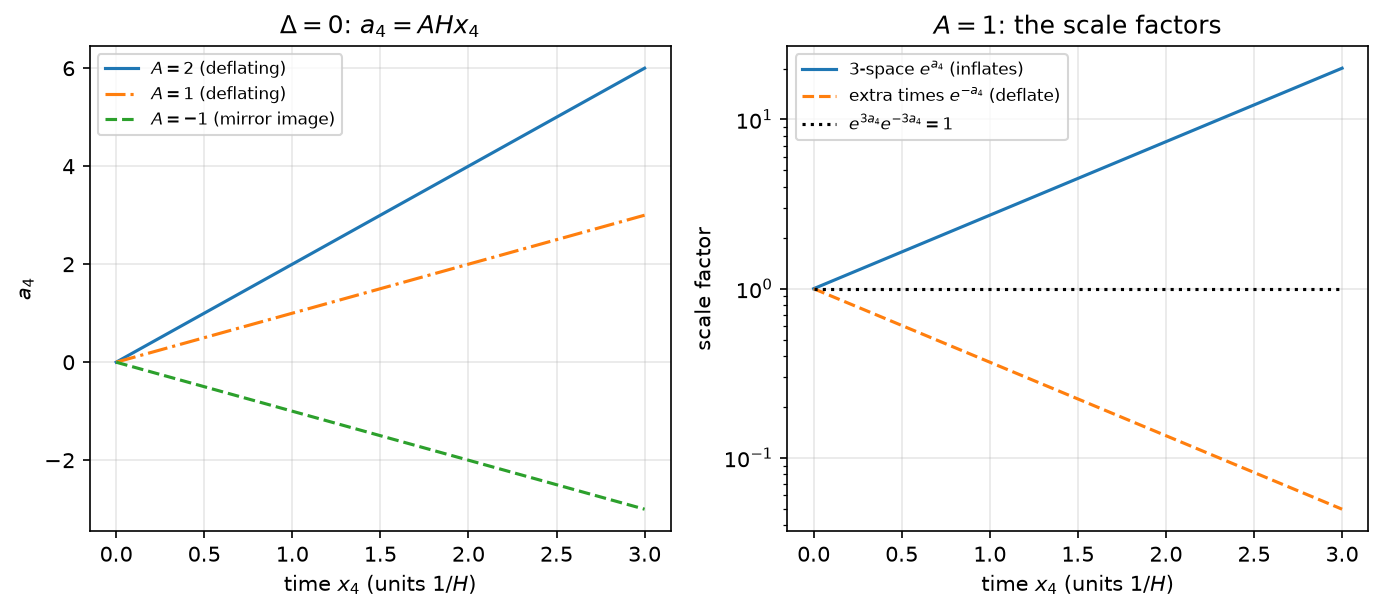

Figure 12c.1 saved as Revision/textbook/figures/12c_1_linear_member.png


In [6]:
fig, (left, right) = plt.subplots(1, 2, figsize=(11.0, 4.2))
for slope, style, words in ((2.0, "-", "deflating"), (1.0, "-.", "deflating"),
                            (-1.0, "--", "mirror image")):
    x4, y = linear[slope]
    left.plot(x4, y[:, 0], style, label=f"$A = {slope:g}$ ({words})")
left.set_xlabel("time $x_4$ (units $1/H$)")
left.set_ylabel("$a_4$")
left.set_title("$\\Delta = 0$: $a_4 = AHx_4$")
left.legend(fontsize=8)
x4, y = linear[1.0]
right.semilogy(x4, np.exp(y[:, 0]), label="3-space $e^{a_4}$ (inflates)")
right.semilogy(x4, np.exp(-y[:, 0]), "--", label="extra times $e^{-a_4}$ (deflate)")
right.semilogy(x4, np.exp(3 * y[:, 0]) * np.exp(-3 * y[:, 0]), ":", color="black",
               label="$e^{3a_4}e^{-3a_4} = 1$")
right.set_xlabel("time $x_4$ (units $1/H$)")
right.set_ylabel("scale factor")
right.set_title("$A = 1$: the scale factors")
right.legend(fontsize=8)
save_figure(fig, "linear_member",
            "Without anisotropic stress ($p_3 = p_t$) the evolution equation gives "
            "$a_4^{\\prime\\prime} = 0$. Left: the numerical histories $a_4(x_4)$ "
            "for the deflating rates $A = 2$ (solid) and $A = 1$ (dash-dotted) and "
            "for the mirror image $A = -1$ (dashed; inflating extra times, which "
            "the equations allow equally), straight lines "
            "$a_4 = AHx_4$; horizontal axis the time $x_4$ in units of $1/H$. Right: "
            "for $A = 1$ the scale factor $e^{a_4}$ of 3-space (inflating) and "
            "$e^{-a_4}$ of the extra times (deflating exponentially) on a "
            "logarithmic axis, and the constant product $e^{3a_4}e^{-3a_4} = 1$: "
            "what 3-space gains, the extra times lose.")

## 8. A pulse of anisotropic stress raises the deflation rate

Now we start on the canonical history, the deflating linear member with $A = 1$
($a_4(0) = 0$, $a_4'(0) = H$), and prescribe a short pulse of stress around the
time $x_c = 3$ with width $w = 0.5$:

$$\kappa\Delta(x_4) = \kappa\Delta_0\,e^{-((x_4 - x_c)/w)^2},\qquad
\kappa\Delta_0 = \frac{2}{w\sqrt\pi}.$$

In Einstein gravity $a_4'' = \kappa\Delta/2$. Integrating once, with
$\int e^{-t^2}dt = \tfrac{\sqrt\pi}{2}\operatorname{erf}(t)$ (erf is the *error
function*; it rises from $-1$ to $1$), and with $H = 1$:

$$a_4'(x_4) = 1 + \frac{\kappa\Delta_0 w\sqrt\pi}{4}\Big(\operatorname{erf}
\frac{x_4 - x_c}{w} + \operatorname{erf}\frac{x_c}{w}\Big)
= 1 + \frac12\Big(\operatorname{erf}\frac{x_4 - x_c}{w}
+ \operatorname{erf}\frac{x_c}{w}\Big),$$

which rises from 1 to almost exactly 2: after the pulse the history is the
deflating linear member with $A = 2$; the extra times deflate at every time, only
faster after the pulse. Integrating again, with
$\int\operatorname{erf}(t)\,dt = t\operatorname{erf}(t) + e^{-t^2}/\sqrt\pi$, gives
$a_4(x_4)$ exactly. The next cell integrates numerically up to $x_4 = 8$ with
$h = 0.01$ and compares both.

In [7]:
X_C, WIDTH = 3.0, 0.5  # the centre and the width of the pulse
PUSH = 2.0 / (WIDTH * math.sqrt(math.pi))  # kappa Delta_0
RATE_START = 1.0  # a4'(0)/H: the canonical deflating history A = 1


def pulse(x, y):
    return PUSH * math.exp(-((x - X_C) / WIDTH) ** 2)  # kappa Delta(x4)


def exact_pulse(x):
    """The exact a4 and a4' of the pulse history (Einstein, a4(0) = 0,
    a4'(0) = 1)."""
    scale = PUSH * WIDTH * math.sqrt(math.pi) / 4  # = 1/2
    t, t0 = (x - X_C) / WIDTH, -X_C / WIDTH  # the argument now and at x4 = 0

    def antiderivative(s):  # an antiderivative of erf
        return s * math.erf(s) + math.exp(-s * s) / math.sqrt(math.pi)

    rate = RATE_START + scale * (math.erf(t) + math.erf(X_C / WIDTH))
    a4 = RATE_START * x + scale * (WIDTH * (antiderivative(t) - antiderivative(t0))
                                   + x * math.erf(X_C / WIDTH))
    return a4, rate


x4_pulse, y_pulse = history(pulse, RATE_START, 0.01, 800)
exact = np.array([exact_pulse(x) for x in x4_pulse])  # columns: a4, a4'
error_a4 = np.max(np.abs(y_pulse[:, 0] - exact[:, 0]))
error_rate = np.max(np.abs(y_pulse[:, 1] - exact[:, 1]))
say(f"largest error: a4 {error_a4:.0e}, a4' {error_rate:.0e}")
check(error_a4 < 1e-8 and error_rate < 1e-8,
      "pulse: RK4 (h = 0.01) agrees with the exact solution to 1e-8")
check(np.min(y_pulse[:, 1]) >= 1.0 - 1e-12,
      "the rate a4' never falls below H: the extra times deflate at every time")
report("rate a4'/H after the pulse (x4 = 8)", f"{y_pulse[-1, 1]:.10f}")
check(abs(y_pulse[-1, 1] - 2.0) < 1e-8,
      "after the pulse a4' = 2 H: the deflating linear member A = 2")

largest error: a4 9e-11, a4' 1e-10
PASS pulse: RK4 (h = 0.01) agrees with the exact solution to 1e-8
PASS the rate a4' never falls below H: the extra times deflate at every time
RESULT rate a4'/H after the pulse (x4 = 8) = 2.0000000000
PASS after the pulse a4' = 2 H: the deflating linear member A = 2


The next cell draws the pulse history in four panels: the prescribed stress; the
rate $a_4'$ (numerical line and exact points); $a_4$ itself; and the two scale
factors on a logarithmic axis.

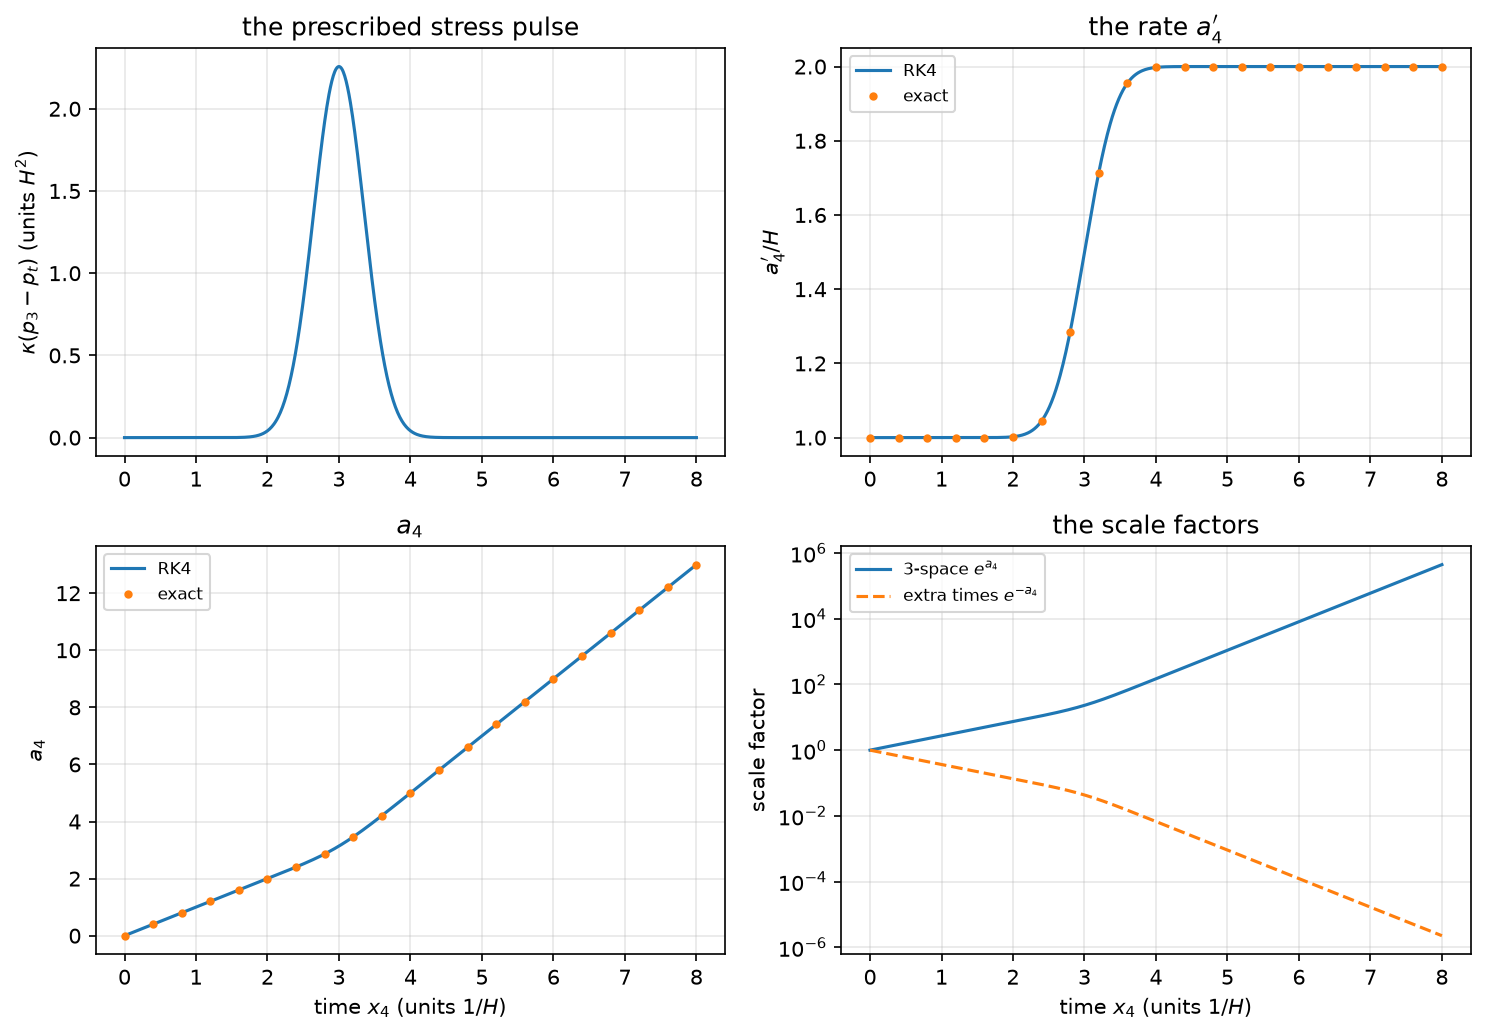

Figure 12c.2 saved as Revision/textbook/figures/12c_2_stress_pulse.png


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(10.0, 7.0))
stress_values = np.array([pulse(x, None) for x in x4_pulse])
axes[0, 0].plot(x4_pulse, stress_values)
axes[0, 0].set_ylabel("$\\kappa(p_3 - p_t)$ (units $H^2$)")
axes[0, 0].set_title("the prescribed stress pulse")
every = slice(0, None, 40)  # every 40th point for the exact markers
axes[0, 1].plot(x4_pulse, y_pulse[:, 1], label="RK4")
axes[0, 1].plot(x4_pulse[every], exact[every, 1], "o", markersize=3, label="exact")
axes[0, 1].set_ylabel("$a_4'/H$")
axes[0, 1].set_title("the rate $a_4'$")
axes[0, 1].legend(fontsize=8)
axes[1, 0].plot(x4_pulse, y_pulse[:, 0], label="RK4")
axes[1, 0].plot(x4_pulse[every], exact[every, 0], "o", markersize=3, label="exact")
axes[1, 0].set_ylabel("$a_4$")
axes[1, 0].set_title("$a_4$")
axes[1, 0].legend(fontsize=8)
axes[1, 1].semilogy(x4_pulse, np.exp(y_pulse[:, 0]), label="3-space $e^{a_4}$")
axes[1, 1].semilogy(x4_pulse, np.exp(-y_pulse[:, 0]), "--",
                    label="extra times $e^{-a_4}$")
axes[1, 1].set_ylabel("scale factor")
axes[1, 1].set_title("the scale factors")
axes[1, 1].legend(fontsize=8)
for ax in axes[1]:
    ax.set_xlabel("time $x_4$ (units $1/H$)")
fig.tight_layout()
save_figure(fig, "stress_pulse",
            "Einstein gravity, starting on the deflating linear member $A = 1$ "
            "($a_4 = 0$, $a_4' = H$): a prescribed pulse of anisotropic stress "
            "$\\kappa(p_3 - p_t)$ centred at $x_4 = 3$ (top left, units $H^2$) raises "
            "the rate $a_4'$ from $H$ to $2H$ (top right); $a_4$ grows linearly with "
            "slope 1 before the pulse and with slope 2 after it (bottom left): the "
            "history moves from the linear member $A = 1$ to $A = 2$. Bottom right: "
            "on a logarithmic axis the scale factor $e^{a_4}$ of 3-space inflates and "
            "$e^{-a_4}$ of the extra times deflates exponentially at every time, "
            "twice as fast after the pulse. Lines: RK4 with step $h = 0.01$; dots: "
            "the exact solution with the error function. Horizontal axes: the time "
            "$x_4$ in units of $1/H$.")

## 9. The source the pulse history requires, and the constraint

Along the pulse history the field equations fix the whole source (with
$\Lambda = 0$):

$$\kappa\rho = -(3(a_4')^2 + 21),\quad \kappa p_8 = 15 - 3(a_4')^2,\quad
\kappa p_3 = \kappa p_8 + \tfrac12\kappa\Delta,\quad
\kappa p_t = \kappa p_8 - \tfrac12\kappa\Delta.$$

The third component of our state, $\kappa\rho$ integrated from the conservation law
$\rho' = -3a_4'\Delta$, must agree with the $\kappa\rho$ that the constraint gives
at every time: this is the numerical form of the record's proof that the
derivative of the constraint is $3a_4'$ times the evolution equation. The next
cell defines a small helper that writes the measured disagreement as a power of
ten for the caption, checks the agreement, checks that the source starts on the
values of the linear member $A = 1$ ($\kappa\rho = -(3 + 21) = -24$,
$\kappa p = 15 - 3 = 12$) and ends on those of $A = 2$
($\kappa\rho = -(12 + 21) = -33$, $\kappa p = 15 - 12 = 3$), and draws the four
source components and the size of the disagreement.

largest difference of the two energy densities: 2e-11
PASS the energy density from conservation equals the constraint along x4
     reproduces Revision/field_equations_a4/reports/wolfram-a4-report.json, check
    constraint_propagation_bianchi
PASS before the pulse: kappa rho = -24, kappa p = 12 (the linear member A = 1)
PASS after the pulse: kappa rho = -33, kappa p = 3 (the linear member A = 2)


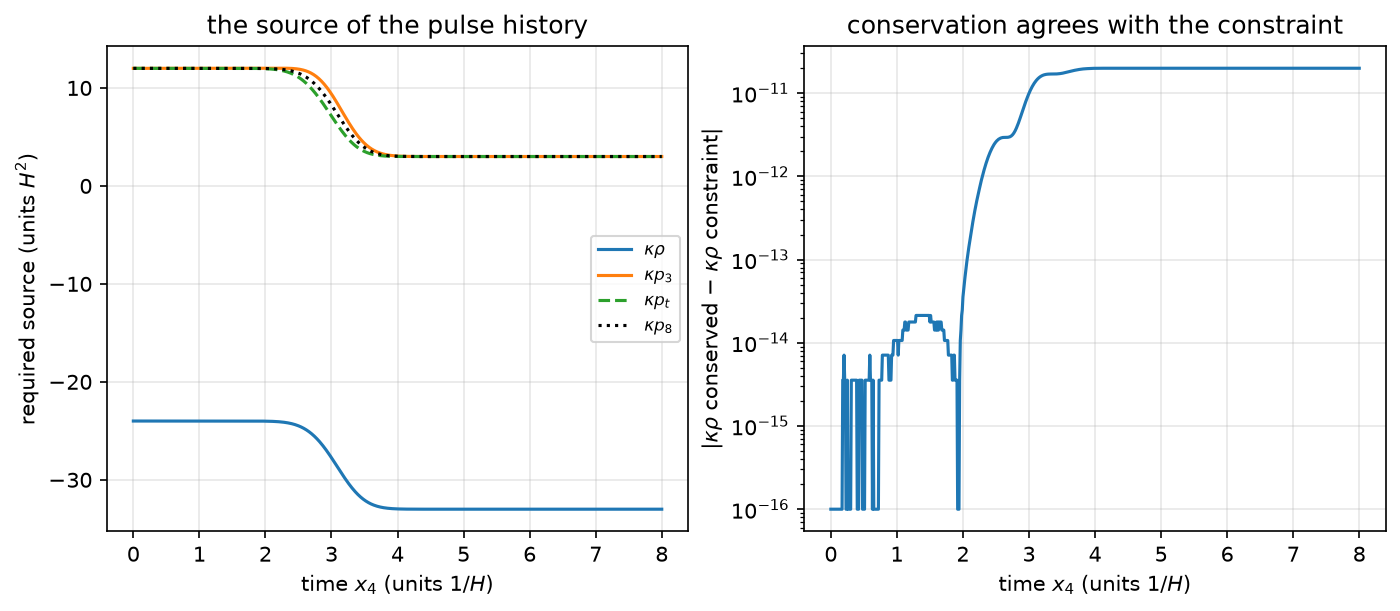

Figure 12c.3 saved as Revision/textbook/figures/12c_3_required_source.png


In [9]:
def as_power_of_ten(value):
    """A positive number rounded to one digit, written for a caption:
    2e-11 becomes $2 \\times 10^{-11}$."""
    mantissa, exponent = f"{value:.0e}".split("e")
    return f"${mantissa} \\times 10^{{{int(exponent)}}}$"


rate = y_pulse[:, 1]
rho_constraint = -(rho_side(rate, *EINSTEIN) + 0.0)  # kappa rho, Lambda = 0
p8_values = p8_side(rate, *EINSTEIN) + 0.0  # kappa p8
p3_values = p8_values + stress_values / 2  # kappa p3
pt_values = p8_values - stress_values / 2  # kappa pt
mismatch = np.abs(y_pulse[:, 2] - rho_constraint)  # conservation versus constraint
say(f"largest difference of the two energy densities: {mismatch.max():.0e}")
reproduces(mismatch.max() < 1e-8,
           "the energy density from conservation equals the constraint along x4",
           WL, "constraint_propagation_bianchi")
check(abs(rho_constraint[0] + 24) < 1e-6 and abs(p8_values[0] - 12) < 1e-6,
      "before the pulse: kappa rho = -24, kappa p = 12 (the linear member A = 1)")
check(abs(rho_constraint[-1] + 33) < 1e-6 and abs(p8_values[-1] - 3) < 1e-6,
      "after the pulse: kappa rho = -33, kappa p = 3 (the linear member A = 2)")
fig, (left, right) = plt.subplots(1, 2, figsize=(11.0, 4.2))
left.plot(x4_pulse, rho_constraint, label="$\\kappa\\rho$")
left.plot(x4_pulse, p3_values, label="$\\kappa p_3$")
left.plot(x4_pulse, pt_values, "--", label="$\\kappa p_t$")
left.plot(x4_pulse, p8_values, ":", color="black", label="$\\kappa p_8$")
left.set_xlabel("time $x_4$ (units $1/H$)")
left.set_ylabel("required source (units $H^2$)")
left.set_title("the source of the pulse history")
left.legend(fontsize=8)
right.semilogy(x4_pulse, np.maximum(mismatch, 1e-16))  # exact zeros at 1e-16
right.set_xlabel("time $x_4$ (units $1/H$)")
right.set_ylabel("$|\\kappa\\rho$ conserved $-$ $\\kappa\\rho$ constraint$|$")
right.set_title("conservation agrees with the constraint")
save_figure(fig, "required_source",
            "Left: the source that the pulse history requires in Einstein gravity "
            "with $\\Lambda = 0$, in units of $H^2$: the energy density $\\kappa\\rho$, "
            "the pressures $\\kappa p_3$ (3-space), $\\kappa p_t$ (extra times, "
            "dashed) and $\\kappa p_8$ (hidden direction, dotted). During the pulse "
            "$p_3$ and $p_t$ split by the prescribed stress; before it the source "
            "is that of the linear member $A = 1$ ($\\kappa\\rho = -24$, "
            "$\\kappa p = 12$), after it that of the linear member $A = 2$ "
            "($\\kappa\\rho = -33$, $\\kappa p = 3$). Right: on a logarithmic axis, "
            "the difference between "
            "the energy density integrated from the conservation law and the one "
            "given by the constraint (an exact zero is drawn at $10^{-16}$). The two "
            f"agree to about {as_power_of_ten(mismatch.max())}, the accuracy of the "
            "RK4 integration with the step $h = 0.01$.")

## 10. A stress that relaxes the deflation rate

A stress can also depend on the state. We start on the faster deflating member
$A = 2$ ($a_4'(0) = 2H$) and prescribe
$\kappa\Delta = -2\eta\,(a_4' - H)$ with a constant $\eta > 0$: a resistance
proportional to the excess of the rate over $H$, like friction. In Einstein
gravity $a_4'' = \kappa\Delta/2 = -\eta(a_4' - H)$; the excess $u = a_4' - H$
obeys $u' = -\eta u$, so $u = He^{-\eta x_4}$ and, with $H = 1$,

$$a_4' = 1 + e^{-\eta x_4},\qquad
a_4 = x_4 + \frac{1}{\eta}\big(1 - e^{-\eta x_4}\big).$$

The deflation rate relaxes from $2H$ to $H$: the history moves smoothly from the
linear member $A = 2$ to $A = 1$, and the extra-time scale factor $e^{-a_4}$
shrinks exponentially at every time, first at the rate $2H$, later at the rate
$H$. The next cell integrates this for $\eta = 0.25, 0.5, 1$ up to $x_4 = 10$,
compares with the exact solution, and checks the conservation law, which here
reads $\kappa\rho' = -3a_4'\kappa\Delta = 6\eta\,a_4'(a_4' - 1) > 0$: the energy
density rises from $-33$ (the value of $A = 2$) towards $-24$ (the value of
$A = 1$), in units of $H^2/\kappa$.

In [10]:
damped = {}  # eta -> (x4, solution)
for eta in (0.25, 0.5, 1.0):
    def friction(x, y, eta=eta):
        return -2.0 * eta * (y[1] - 1.0)  # kappa Delta = -2 eta (a4' - H)

    x4, y = history(friction, 2.0, 0.01, 1000)  # start on A = 2
    damped[eta] = (x4, y)
    exact_a4 = x4 + (1.0 / eta) * (1.0 - np.exp(-eta * x4))
    error = np.max(np.abs(y[:, 0] - exact_a4))
    mismatch = np.max(np.abs(y[:, 2] + rho_side(y[:, 1], *EINSTEIN)))
    check(error < 1e-9 and mismatch < 1e-8,
          f"eta = {eta}: a4 = x4 + (1 - e^(-eta x4))/eta, conservation holds")
    check(np.min(y[:, 1]) > 1.0,
          f"eta = {eta}: the rate a4' stays above H (the extra times deflate)")
    report(f"eta = {eta}: rate a4'/H at x4 = 10", f"{y[-1, 1]:.6f}")

PASS eta = 0.25: a4 = x4 + (1 - e^(-eta x4))/eta, conservation holds
PASS eta = 0.25: the rate a4' stays above H (the extra times deflate)
RESULT eta = 0.25: rate a4'/H at x4 = 10 = 1.082085
PASS eta = 0.5: a4 = x4 + (1 - e^(-eta x4))/eta, conservation holds
PASS eta = 0.5: the rate a4' stays above H (the extra times deflate)
RESULT eta = 0.5: rate a4'/H at x4 = 10 = 1.006738
PASS eta = 1.0: a4 = x4 + (1 - e^(-eta x4))/eta, conservation holds
PASS eta = 1.0: the rate a4' stays above H (the extra times deflate)
RESULT eta = 1.0: rate a4'/H at x4 = 10 = 1.000045


The next cell draws the rate $a_4'$ and the extra-time scale factor $e^{-a_4}$ for
the three values of $\eta$, together with the two linear members $A = 2$ and
$A = 1$ (dotted) between which the histories move.

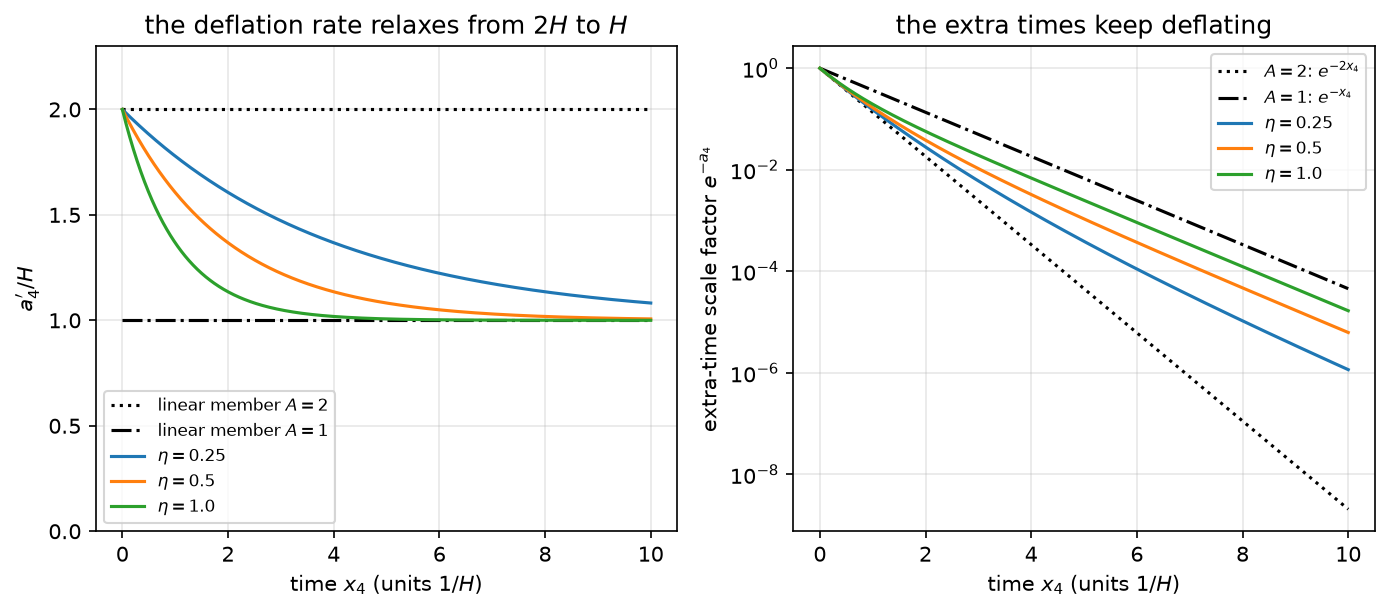

Figure 12c.4 saved as Revision/textbook/figures/12c_4_damped_deflation.png


In [11]:
fig, (left, right) = plt.subplots(1, 2, figsize=(11.0, 4.2))
x4 = damped[0.25][0]
for slope, style, power in ((2.0, ":", "-2x_4"), (1.0, "-.", "-x_4")):
    left.plot(x4, slope * np.ones_like(x4), style, color="black",
              label=f"linear member $A = {slope:g}$")  # the two linear members
    right.semilogy(x4, np.exp(-slope * x4), style, color="black",
                   label=f"$A = {slope:g}$: $e^{{{power}}}$")
for eta, (x4, y) in damped.items():
    left.plot(x4, y[:, 1], label=f"$\\eta = {eta}$")
    right.semilogy(x4, np.exp(-y[:, 0]), label=f"$\\eta = {eta}$")
left.set_ylim(0.0, 2.3)
left.set_xlabel("time $x_4$ (units $1/H$)")
left.set_ylabel("$a_4'/H$")
left.set_title("the deflation rate relaxes from $2H$ to $H$")
left.legend(fontsize=8)
right.set_xlabel("time $x_4$ (units $1/H$)")
right.set_ylabel("extra-time scale factor $e^{-a_4}$")
right.set_title("the extra times keep deflating")
right.legend(fontsize=8)
save_figure(fig, "damped_deflation",
            "Einstein gravity with the prescribed relaxing stress "
            "$\\kappa(p_3 - p_t) = -2\\eta(a_4' - H)$, starting on the deflating "
            "linear member $A = 2$: left, the rate $a_4' = H(1 + e^{-\\eta x_4})$ for "
            "$\\eta = 0.25$, $0.5$ and $1$ (units $H$), which relaxes from $2H$ to "
            "$H$, with the linear members $A = 2$ and $A = 1$ in black; right, the "
            "scale factor $e^{-a_4}$ of the extra times on a logarithmic axis, which "
            "falls exponentially at every time: first as fast as for $A = 2$ "
            "(slope $-2$), later as for $A = 1$ (slope $-1$). The extra times never "
            "stop deflating. Horizontal axes: the time $x_4$ in units of $1/H$.")

## 11. How fast does RK4 converge?

For the relaxing history the right-hand side depends on the solution itself, so
it is a genuine differential equation and a good test of the method. (For the
pulse the stress depends on $x_4$ alone; RK4 then reduces to Simpson's rule for an
integrand that vanishes smoothly at both ends, and such integrals converge much
faster than $h^4$, which would hide the order.) The next cell integrates the
relaxing history with $\eta = 1$ up to $x_4 = 8$ with the step sizes
$h = 0.4, 0.2, 0.1, 0.05, 0.025$ and measures the error of $a_4(8)$ against the
exact value $8 + (1 - e^{-8})$. If the error behaves like $Ch^4$, halving $h$
divides it by $2^4 = 16$, and the measured order $\log_2(e_h / e_{h/2})$ is close
to 4. The table prints each step, its error and the order; the plot shows the
errors on logarithmic axes, where $Ch^4$ is a straight line of slope 4.

h = 0.4    error of a4(8) = 8.01e-07   measured order -
h = 0.2    error of a4(8) = 4.23e-08   measured order 4.24
h = 0.1    error of a4(8) = 2.43e-09   measured order 4.12
h = 0.05   error of a4(8) = 1.46e-10   measured order 4.06
h = 0.025  error of a4(8) = 8.92e-12   measured order 4.03
PASS RK4 converges with order 4 (measured orders between 3.7 and 4.3)


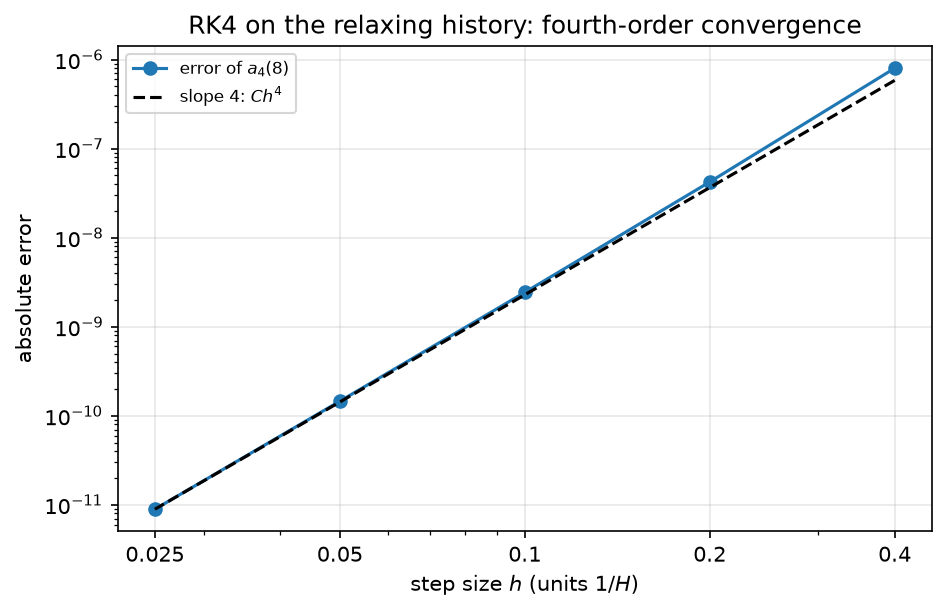

Figure 12c.5 saved as Revision/textbook/figures/12c_5_rk4_convergence.png


In [12]:
def relaxing_unit(x, y):
    return -2.0 * (y[1] - 1.0)  # kappa Delta = -2 eta (a4' - H) with eta = 1


exact_end = 8.0 + (1.0 - math.exp(-8.0))  # the exact a4(8) for eta = 1
steps_list = [20, 40, 80, 160, 320]  # h = 8/steps = 0.4, 0.2, 0.1, 0.05, 0.025
sizes, errors = [], []
for steps in steps_list:
    x4, y = history(relaxing_unit, 2.0, 8.0 / steps, steps)
    sizes.append(8.0 / steps)
    errors.append(abs(y[-1, 0] - exact_end))
orders = [math.log2(errors[i] / errors[i + 1]) for i in range(len(errors) - 1)]
for i, (size, error) in enumerate(zip(sizes, errors)):
    order = f"{orders[i - 1]:.2f}" if i > 0 else "-"
    say(f"h = {size:<6} error of a4(8) = {error:.2e}   measured order {order}")
check(all(3.7 < q < 4.3 for q in orders),
      "RK4 converges with order 4 (measured orders between 3.7 and 4.3)")
fig, ax = plt.subplots()
ax.loglog(sizes, errors, "o-", label="error of $a_4(8)$")
reference = errors[-1] * (np.array(sizes) / sizes[-1]) ** 4
ax.loglog(sizes, reference, "--", color="black", label="slope 4: $C h^4$")
ax.set_xticks(sizes)  # one tick at each step size used
ax.set_xticklabels([f"{size:g}" for size in sizes])
ax.xaxis.set_minor_formatter(matplotlib.ticker.NullFormatter())  # no extra labels
ax.set_xlabel("step size $h$ (units $1/H$)")
ax.set_ylabel("absolute error")
ax.set_title("RK4 on the relaxing history: fourth-order convergence")
ax.legend(fontsize=8)
save_figure(fig, "rk4_convergence",
            "The error of the RK4 value of $a_4$ at $x_4 = 8$ for the relaxing "
            "history with $\\eta = 1$ (exact value $8 + 1 - e^{-8}$), for the step "
            "sizes $h = 0.4$, $0.2$, $0.1$, $0.05$ and $0.025$ (units $1/H$), on "
            "logarithmic axes. The points follow the dashed reference line $Ch^4$ "
            "of slope 4: halving the step divides the error by about 16, the "
            "fourth-order convergence of the Runge-Kutta method.")

## 12. Einstein-Gauss-Bonnet gravity: the evolution equation breaks down

With the Gauss-Bonnet coupling ($\alpha_1 = 1$, $\alpha_3 = 0$, $H = 1$),
$F(a_4') = 2 - 80\alpha_2 - 48\alpha_2(a_4')^2$ decreases as $|a_4'|$ grows and
vanishes at $a_4'_c = \sqrt{(2 - 80\alpha_2)/(48\alpha_2)}$. For a constant stress
$\kappa\Delta$ the equation $F(a_4')\,a_4'' = \kappa\Delta$ can be integrated
once: with $G(v) = (2 - 80\alpha_2)v - 16\alpha_2v^3$ (so that $dG/dv = F$),

$$G(a_4'(x_4)) = G(a_4'(0)) + \kappa\Delta\,x_4 .$$

$G$ has its maximum at $a_4'_c$, so the rate reaches $a_4'_c$ at the finite time
$x_4^{\star} = (G(a_4'_c) - G(a_4'(0)))/(\kappa\Delta)$, with $a_4'' = \kappa\Delta/F$
growing without bound; beyond it the equation has no solution with a smooth
$a_4'$. The next cell starts on the canonical deflating member ($a_4'(0) = H$),
integrates with $\kappa\Delta = 0.5$ and $\alpha_2 = 0.005, 0.01$ (step
$h = 0.001$), stops when $F < 0.05$, and checks the integrated relation and the
breakdown time.

In [13]:
STRESS, RATE0 = 0.5, 1.0  # kappa Delta and the starting rate a4'(0) = H (A = 1)


def constant_stress(x, y):
    return STRESS


breakdown = {}  # alpha2 -> (x4, solution, predicted breakdown time)
for alpha2 in (0.005, 0.01):
    couplings = (1.0, alpha2, 0.0)

    def G(v, alpha2=alpha2):
        return (2 - 80 * alpha2) * v - 16 * alpha2 * v ** 3  # dG/dv = F

    critical = math.sqrt((2 - 80 * alpha2) / (48 * alpha2))  # F(critical) = 0
    x_star = (G(critical) - G(RATE0)) / STRESS  # the breakdown time

    def near_zero(y, couplings=couplings):
        return F_of(y[1], *couplings) < 0.05  # stop before F reaches zero

    x4, y = history(constant_stress, RATE0, 0.001, 20000, couplings,
                    stop=near_zero)
    breakdown[alpha2] = (x4, y, x_star)
    residual = np.max(np.abs(G(y[:, 1]) - G(RATE0) - STRESS * x4))
    check(residual < 1e-6, f"alpha2 = {alpha2}: G(a4') = G(a4'(0)) + kappa Delta x4")
    check(abs(x4[-1] - x_star) < 0.01,
          f"alpha2 = {alpha2}: F reaches 0 near the predicted time x4*")
    report(f"alpha2 = {alpha2}: critical rate, breakdown time x4*",
           f"{critical:.4f} H, {x_star:.4f}/H")

PASS alpha2 = 0.005: G(a4') = G(a4'(0)) + kappa Delta x4
PASS alpha2 = 0.005: F reaches 0 near the predicted time x4*
RESULT alpha2 = 0.005: critical rate, breakdown time x4* = 2.5820 H, 2.4682/H
PASS alpha2 = 0.01: G(a4') = G(a4'(0)) + kappa Delta x4
PASS alpha2 = 0.01: F reaches 0 near the predicted time x4*
RESULT alpha2 = 0.01: critical rate, breakdown time x4* = 1.5811 H, 0.4498/H


The next cell compares the two Gauss-Bonnet histories with Einstein gravity, where
$F = 2$ and the rate simply grows linearly, $a_4' = 1 + 0.25x_4$, and draws
$F(a_4'(x_4))$ along each history.

PASS Einstein: a4' = 1 + 0.25 x4 for the constant stress


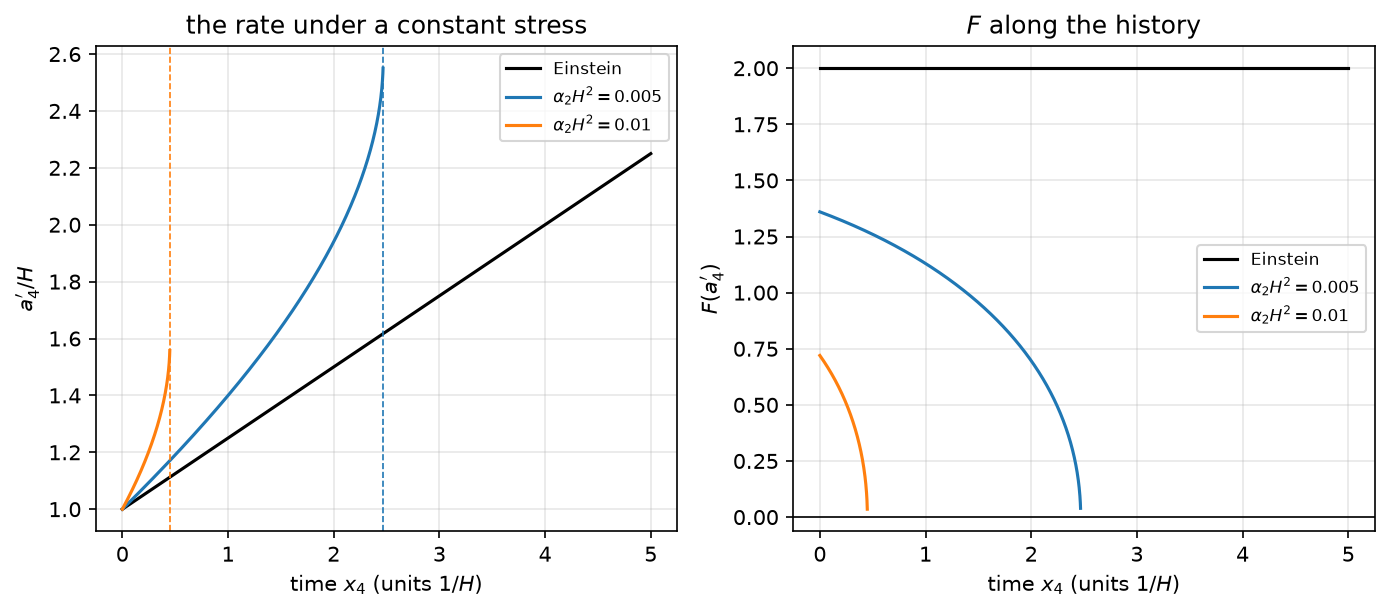

Figure 12c.6 saved as Revision/textbook/figures/12c_6_gauss_bonnet_breakdown.png


In [14]:
x_einstein, y_einstein = history(constant_stress, RATE0, 0.01, 500)
check(np.max(np.abs(y_einstein[:, 1] - (RATE0 + STRESS * x_einstein / 2))) < 1e-12,
      "Einstein: a4' = 1 + 0.25 x4 for the constant stress")
fig, (left, right) = plt.subplots(1, 2, figsize=(11.0, 4.2))
left.plot(x_einstein, y_einstein[:, 1], color="black", label="Einstein")
right.plot(x_einstein, F_of(y_einstein[:, 1], *EINSTEIN) * np.ones_like(x_einstein),
           color="black", label="Einstein")
for alpha2, (x4, y, x_star) in breakdown.items():
    line = left.plot(x4, y[:, 1], label=f"$\\alpha_2H^2 = {alpha2}$")[0]
    left.axvline(x_star, linestyle="--", color=line.get_color(), linewidth=0.8)
    right.plot(x4, F_of(y[:, 1], 1.0, alpha2, 0.0), color=line.get_color(),
               label=f"$\\alpha_2H^2 = {alpha2}$")
left.set_xlabel("time $x_4$ (units $1/H$)")
left.set_ylabel("$a_4'/H$")
left.set_title("the rate under a constant stress")
left.legend(fontsize=8)
right.axhline(0.0, color="black", linewidth=0.8)
right.set_xlabel("time $x_4$ (units $1/H$)")
right.set_ylabel("$F(a_4')$")
right.set_title("$F$ along the history")
right.legend(fontsize=8)
save_figure(fig, "gauss_bonnet_breakdown",
            "A constant prescribed stress $\\kappa(p_3 - p_t) = 0.5H^2$ starting on "
            "the deflating linear member $A = 1$ ($a_4' = H$). Left: the rate $a_4'$ "
            "in Einstein gravity grows "
            "linearly (black), while in Einstein-Gauss-Bonnet gravity with "
            "$\\alpha_2H^2 = 0.005$ and $0.01$ it bends upward and reaches the "
            "critical rate at the predicted finite time $x_4^{\\star}$ (dashed vertical "
            "lines), where its slope becomes infinite. Right: the factor $F(a_4')$ "
            "of the evolution equation along each history; the integration stops "
            "when $F$ falls below $0.05$, because at $F = 0$ the evolution equation "
            "breaks down. Horizontal axes: the time $x_4$ in units of $1/H$.")

## 13. Which sources are real? The record on the Kohn-Sham states

The stresses above were chosen by hand. The Revision record asks the opposite
question for the only many-particle states it has computed, the Kohn-Sham states
of dirac16complex: can they be the source of the author's metric? The next cell
reads the record's answer, prints how many of its checks passed and checks that
every one did. The answer is no: every nonzero Kohn-Sham state depends on $x_8$
and violates $p_3 + p_t = 2p_8$, so the Kohn-Sham history $a_4 = AHx_4$ is a
prescribed background, not a solution of these equations with that source.

In [15]:
ks = read_json(KS)
say("record: " + ks["conclusion"])
detail = {entry["name"]: entry["detail"] for entry in ks["checks"]}
verdicts = [entry["verdict"] for entry in ks["checks"]]
passed = verdicts.count("PASS")  # how many checks of the record passed
say(f"{KS}: {passed} of {len(verdicts)} checks PASS")
check(len(verdicts) > 0 and passed == len(verdicts) == ks["summary"]["checks"]
      and "ks_history_is_a_prescribed_background" in detail,
      "record: no Kohn-Sham state is an admissible source (every check PASS)")

record: No Kohn-Sham state recorded in Revision/kohn_sham is an admissible source of the
    author's metric: C1 and C2 fail for every nonzero state (C2 also after integration
    over x8), and the Kohn-Sham history uses the linear member as a prescribed
    background, without back-reaction.
Revision/field_equations_a4/reports/ks-source-conditions.json: 5 of 5 checks PASS
PASS record: no Kohn-Sham state is an admissible source (every check PASS)


## 14. The record's numbers, recomputed from the Kohn-Sham table

The record does not only say no; it gives numbers. We recompute them here from
the table `emt-integrals.csv` of the Kohn-Sham record, which holds one row per
recorded ground state: its name (for example `N136_lam0_a10`: $N = 136$
particles, coupling $\lambda = 0$, slice $a_{4,0} = 1$) and the integrals over
the hidden direction, $2\,\mathrm{Vol}_7\int e^{6Hy}\,T\,dy$, of the energy
density and of the three pressures (columns `int_rho`, `int_p3`, `int_p_t`,
`int_p8`). If the source obeyed $p_3 + p_t = 2p_8$ at every point, it would also
obey it after the integration, and the ratio
$$r = \frac{\int p_3 + \int p_t}{2\int p_8}$$
would be exactly 1. The next cell

- counts the states, and those whose four integrals are not all zero (a state
  with a zero energy-momentum tensor is no source at all);
- computes $r$ for every other state, finds the one closest to 1, and prints $r$
  for the history $N = 136$, $\lambda = 0$ at the slices $a_{4,0} = 0, 1, 2$;
- compares every number with the text of the record, which prints them with six
  significant digits (the format `.6g`), so that a change of either is caught.

In [16]:
import csv  # reads tables of comma-separated values
import re  # regular expressions: find a pattern in a text

TABLE = "Revision/kohn_sham/results/ground/emt-integrals.csv"
with repository_file(TABLE).open(encoding="utf-8", newline="") as handle:
    table = {row["id"]: row for row in csv.DictReader(handle)}
INTEGRALS = ("int_rho", "int_p3", "int_p_t", "int_p8")  # 2 Vol_7 int e^(6Hy) T dy
zero = sorted(name for name, row in table.items()
              if all(float(row[column]) == 0.0 for column in INTEGRALS))
nonzero = [name for name in table if name not in zero]
report("Kohn-Sham states in the table", len(table))
report("states with a nonzero energy-momentum tensor", len(nonzero))
say("states with a zero energy-momentum tensor: " + ", ".join(zero))

counted = re.search(r"(\d+) ground-state profiles .*?\((\d+) with a nonzero",
                    detail["ks_profiles_depend_on_x8"])
reproduces(counted is not None
           and counted.groups() == (str(len(table)), str(len(nonzero))),
           f"{len(nonzero)} of the {len(table)} states have a nonzero tensor",
           KS, "ks_profiles_depend_on_x8")
listed = detail["ks_zero_source_states_listed"].rsplit(": ", 1)[-1].split(", ")
reproduces(sorted(listed) == zero,
           "the states with a zero tensor are the ones the record lists",
           KS, "ks_zero_source_states_listed")

ratio = {}  # r = (int p3 + int p_t)/(2 int p8) of every nonzero state
for name in nonzero:
    row = table[name]
    if float(row["int_p8"]) != 0.0:
        ratio[name] = ((float(row["int_p3"]) + float(row["int_p_t"]))
                       / (2 * float(row["int_p8"])))
closest = min(ratio, key=lambda name: abs(ratio[name] - 1.0))
report(f"closest to 1: r of {closest}", f"{ratio[closest]:.6g}")
HISTORY = ["N136_lam0_a00", "N136_lam0_a10", "N136_lam0_a20"]  # N = 136, lambda = 0
for name in HISTORY:
    slice_a4 = float(table[name]["a4"])  # the slice a4,0 of this state
    report(f"N = 136, lambda = 0, a4,0 = {slice_a4:g}: r", f"{ratio[name]:.6g}")

text = detail["ks_integrals_violate_algebraic_condition"]
tolerance = float(ks["tolerance"].split()[-1])  # "relative 1e-06" gives 1e-06
best = re.search(r"closest to 1: (\S+) at (\w+)", text)
reproduces(len(ratio) == len(nonzero) and abs(ratio[closest] - 1.0) > tolerance
           and best is not None
           and best.groups() == (f"{ratio[closest]:.6g}", closest),
           "r differs from 1 for every nonzero state; the closest as recorded",
           KS, "ks_integrals_violate_algebraic_condition")
found = [re.search(name + r": (\S+?)[,\s]", text) for name in HISTORY]
reproduces(all(item is not None and item.group(1) == f"{ratio[name]:.6g}"
               for item, name in zip(found, HISTORY)),
           "r of N = 136, lambda = 0 at a4,0 = 0, 1, 2 equals the record",
           KS, "ks_integrals_violate_algebraic_condition")

RESULT Kohn-Sham states in the table = 75
RESULT states with a nonzero energy-momentum tensor = 70
states with a zero energy-momentum tensor: N8_lam0_a00, N8_lam0_a05, N8_lam0_a10,
    N8_lam0_a15, N8_lam0_a20
PASS 70 of the 75 states have a nonzero tensor
     reproduces Revision/field_equations_a4/reports/ks-source-conditions.json, check
    ks_profiles_depend_on_x8
PASS the states with a zero tensor are the ones the record lists
     reproduces Revision/field_equations_a4/reports/ks-source-conditions.json, check
    ks_zero_source_states_listed
RESULT closest to 1: r of N688_lamm2_a00 = 0.414328
RESULT N = 136, lambda = 0, a4,0 = 0: r = 0.339767
RESULT N = 136, lambda = 0, a4,0 = 1: r = 0.25969
RESULT N = 136, lambda = 0, a4,0 = 2: r = 0.239714
PASS r differs from 1 for every nonzero state; the closest as recorded
     reproduces Revision/field_equations_a4/reports/ks-source-conditions.json, check
    ks_integrals_violate_algebraic_condition
PASS r of N = 136, lambda = 0 at a4,0 = 0

## 15. The last check

The last cell checks that the six figure files exist in the folder
Revision/textbook/figures and prints the number of checks that passed.

In [17]:
figure_names = ["linear_member", "stress_pulse", "required_source",
                "damped_deflation", "rk4_convergence", "gauss_bonnet_breakdown"]
paths = [output_file(f"{FIGURE_FOLDER}/12c_{k}_{name}.png")
         for k, name in enumerate(figure_names, 1)]
check(all(path.is_file() for path in paths), "all six figure files exist")
all_checks_passed()

PASS all six figure files exist
ALL 30 CHECKS PASSED (notebook 12c)


## 16. What this notebook showed

- With a prescribed anisotropic stress $p_3 - p_t$ the evolution equation
  $a_4''F(a_4') = \kappa(p_3 - p_t)$ is an ordinary differential equation for
  $a_4(x_4)$, which RK4 solves with fourth-order accuracy (COMPUTED, compared with
  exact solutions).
- No stress gives the linear member $a_4 = AHx_4$: 3-space inflates as
  $e^{AHx_4}$ and the extra times deflate as $e^{-AHx_4}$, with a constant
  7-volume (PROVED, and reproduced numerically).
- A pulse of stress can raise the deflation rate from $H$ to $2H$, and a relaxing
  stress can bring it back to $H$; along both histories the extra times deflate
  exponentially at every time (COMPUTED for ASSUMED stresses).
- The energy density that the conservation law gives equals the one that the
  constraint gives along every history, as the record's Bianchi identity requires
  (COMPUTED).
- In Einstein-Gauss-Bonnet gravity a constant stress drives $a_4'$ to the zero of
  $F$ in a finite time, where the evolution equation breaks down (PROVED by the
  integrated relation, COMPUTED numerically).
- None of these stresses is known to come from a field of the theory; the record
  shows that the Kohn-Sham states of the repository are not admissible sources
  (record ks-source-conditions.json). The notebook recomputes the record's
  numbers from the Kohn-Sham table: the integrated ratio
  $(\int p_3 + \int p_t)/(2\int p_8)$, which must be 1 for an admissible source,
  differs from 1 for every recorded state with a nonzero energy-momentum tensor
  (COMPUTED from the record's table; equal to the record).